# Decision Tree vs Market-Microstructure Baselines

> Demonstrate whether a tuned Decision Tree can outperform Tick Rule, Quote Rule, and Lee-Ready on the same data and evaluation protocol.

**Label convention**
- `True` = sell aggressor
- `False` = buy aggressor

**What this notebook delivers**
- Fully reproducible training + evaluation pipeline
- Confusion matrices for all baselines and Decision Tree 
- Model-selection logic focused on minimizing `FP + FN`

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

def _find_project_root(start: Path) -> Path:
    """Find the nearest parent folder that contains the src package."""
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "src").is_dir() and (p / "task_data").is_dir():
            return p
    for p in candidates:
        if (p / "src").is_dir():
            return p
    raise RuntimeError(
        "Could not find project root containing 'src'. "
        "Open this notebook from the project workspace."
    )

ROOT = _find_project_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data import SYMBOLS, DATES, load_split_with_books, attach_midpoint
from src.features import build_features, FEATURE_NAMES
from src.baselines import tick_rule, quote_rule, lee_ready

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
np.random.seed(42)
print(f"Project root resolved to: {ROOT}")

Project root resolved to: /Users/brzezin/Desktop/trade classification algorithms


In [2]:
# Presentation helper formatting
def _fmt_pct(x):
    return f"{100*x:.2f}%"

def _signed(x):
    return f"{x:+.4f}"

## Agenda

1. Data and feature variants
2. Baseline performance on validation and test
3. Strong Decision Tree tuning strategy
4. Final model and confusion-matrix comparison
5. Presentation summary: did we beat all 3 baselines?

## 1) Dataset and feature design

We evaluate exactly the same symbol-day splits used across the project.

Feature variants:
- `trades_only`: only trade-derived features from price/amount/timestamps.
- `with_midpoint`: same features plus midpoint-distance signals (available here because order book data is provided for evaluation).

Selection strategy: pick the variant and hyperparameters that minimize validation errors (`FP + FN`).

In [3]:
def make_dataset(split: str, use_midpoint_features: bool):
    payload = load_split_with_books(split)

    x_parts = []
    y_parts = []

    for symbol in SYMBOLS:
        trades = payload[symbol]["trades"].copy()
        book = payload[symbol]["orderbook"]

        x = build_features(trades)[FEATURE_NAMES].copy()

        if use_midpoint_features:
            merged = attach_midpoint(trades, book)
            mid = merged["midpoint"]
            x["mid_delta"] = trades["price"] - mid
            x["mid_abs_delta"] = (trades["price"] - mid).abs()
            x["mid_sign"] = np.sign(x["mid_delta"]).astype(float)

        y = trades["side"].astype(bool)

        x_parts.append(x)
        y_parts.append(y)

    x_all = pd.concat(x_parts, axis=0)
    y_all = pd.concat(y_parts, axis=0)
    return x_all, y_all

def fit_imputer(x_train: pd.DataFrame):
    return x_train.median(numeric_only=True)

def apply_imputer(x: pd.DataFrame, med: pd.Series):
    x = x.replace([np.inf, -np.inf], np.nan)
    return x.fillna(med).fillna(0.0)

X_train_t, y_train = make_dataset("train", use_midpoint_features=False)
X_val_t, y_val = make_dataset("val", use_midpoint_features=False)
X_test_t, y_test = make_dataset("test", use_midpoint_features=False)

X_train_m, _ = make_dataset("train", use_midpoint_features=True)
X_val_m, _ = make_dataset("val", use_midpoint_features=True)
X_test_m, _ = make_dataset("test", use_midpoint_features=True)

print("DATES:", DATES)
print("Rows train/val/test:", len(X_train_t), len(X_val_t), len(X_test_t))
print("Features trades_only:", X_train_t.shape[1])
print("Features with_midpoint:", X_train_m.shape[1])

DATES: {'train': '2026-04-12', 'val': '2026-04-13', 'test': '2026-04-14'}
Rows train/val/test: 41967 47276 607949
Features trades_only: 24
Features with_midpoint: 27


## 2) Baselines on validation and test

We compute Tick Rule, Quote Rule, and Lee-Ready on both `val` and `test` so the Decision Tree comparison is apples-to-apples.

In [4]:
def baseline_preds(split: str):
    payload = load_split_with_books(split)
    y_parts, tick_parts, quote_parts, lee_parts = [], [], [], []

    for symbol in SYMBOLS:
        trades = payload[symbol]["trades"]
        book = payload[symbol]["orderbook"]

        y_parts.append(trades["side"].astype(bool))
        tick_parts.append(tick_rule(trades).astype(bool))
        quote_parts.append(quote_rule(trades, book).astype(bool))
        lee_parts.append(lee_ready(trades, book).astype(bool))

    y_true = pd.concat(y_parts, axis=0)
    return {
        "y_true": y_true,
        "Tick Rule": pd.concat(tick_parts, axis=0),
        "Quote Rule": pd.concat(quote_parts, axis=0),
        "Lee-Ready": pd.concat(lee_parts, axis=0),
    }

val_base = baseline_preds("val")
test_base = baseline_preds("test")

def metric_pack(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[False, True])
    tn, fp, fn, tp = cm.ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "errors": int(fp + fn),
    }

val_baseline_rows = []
for k in ["Tick Rule", "Quote Rule", "Lee-Ready"]:
    r = metric_pack(val_base["y_true"], val_base[k])
    r["model"] = k
    val_baseline_rows.append(r)

val_baselines_df = pd.DataFrame(val_baseline_rows).set_index("model").sort_values("errors")
val_baselines_df

/Users/brzezin/Desktop/trade classification algorithms/src/baselines.py:73: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  pred[price < mid] = True
/Users/brzezin/Desktop/trade classification algorithms/src/baselines.py:73: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  pred[price < mid] = True
/Users/brzezin/Desktop/trade classification algorithms/src/baselines.py:73: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  pred[price < mid] = True
/Users/brzezin/Desk

,accuracy,balanced_accuracy,macro_f1,tn,fp,fn,tp,errors
model,,,,,,,,
Quote Rule,0.951519,0.951151,0.951362,21150,1252,1040,23834,2292
Lee-Ready,0.951519,0.951151,0.951362,21150,1252,1040,23834,2292
Tick Rule,0.769312,0.770410,0.769226,17729,4673,6233,18641,10906


## 3) Decision Tree with Time-Series Cross-Validation

Hyperparameters are selected with `GridSearchCV` over `TimeSeriesSplit(n_splits=5)` on the **combined train+val data**.  
`TimeSeriesSplit` respects the temporal ordering of trades — each fold's training window always comes before the validation window, so there is no look-ahead leakage.

A `Pipeline(SimpleImputer → DecisionTreeClassifier)` ensures the median imputation is fitted **only on each fold's training portion** — no statistical leakage from the held-out fold into the imputer.

Tuning dimensions: `max_depth`, `min_samples_leaf`, `min_samples_split`, `criterion`, `class_weight`, `ccp_alpha`.  
Scoring objective: `balanced_accuracy` (averaged across 5 folds).

After CV selects the best parameters, the pipeline is **refit once on the full train+val** data.  
The test split (14 April) is never touched until the final evaluation.

In [5]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import time

# ── Combine train + val for cross-validation ──────────────────────────────────
# Test (April 14) remains strictly held-out until Section 4.
X_tv = pd.concat([X_train_m, X_val_m], axis=0)
y_tv = pd.concat([y_train, y_val], axis=0)

# SimpleImputer cannot handle ±inf — replace them with NaN first
X_tv_clean = X_tv.replace([np.inf, -np.inf], np.nan)

print(f"Train+val size: {len(X_tv_clean):,} rows × {X_tv_clean.shape[1]} features")
print(f"Label balance: {y_tv.mean():.3f} sell / {1 - y_tv.mean():.3f} buy")

# ── Pipeline: impute → tree ───────────────────────────────────────────────────
pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("clf", DecisionTreeClassifier(random_state=42)),
])

# ── Hyperparameter grid ───────────────────────────────────────────────────────
param_grid = {
    "clf__max_depth":          [4, 6, 8],
    "clf__min_samples_leaf":   [20, 50, 100],
    "clf__min_samples_split":  [50, 150],
    "clf__criterion":          ["gini", "log_loss"],
    "clf__class_weight":       [None, "balanced"],
    "clf__ccp_alpha":          [0.0, 1e-4, 1e-3],
}

n_candidates = np.prod([len(v) for v in param_grid.values()])
print(f"\nParameter combinations: {n_candidates}")
print("CV folds: 5 (TimeSeriesSplit)")
print(f"Total fits: {n_candidates * 5:,}")

# ── Time-series CV ────────────────────────────────────────────────────────────
cv = TimeSeriesSplit(n_splits=5)

gs = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1,
    refit=True,   # refit best params on full train+val
    verbose=1,
)

t0 = time.perf_counter()
gs.fit(X_tv_clean, y_tv)
print(f"\nGrid search finished in {time.perf_counter() - t0:.1f}s")
print(f"Best CV balanced_accuracy : {gs.best_score_:.4f}")
print(f"Best params               : {gs.best_params_}")

Train+val size: 89,243 rows × 27 features
Label balance: 0.539 sell / 0.461 buy

Parameter combinations: 216
CV folds: 5 (TimeSeriesSplit)
Total fits: 1,080
Fitting 5 folds for each of 216 candidates, totalling 1080 fits



Grid search finished in 50.3s
Best CV balanced_accuracy : 0.9442
Best params               : {'clf__ccp_alpha': 0.0, 'clf__class_weight': 'balanced', 'clf__criterion': 'gini', 'clf__max_depth': 6, 'clf__min_samples_leaf': 20, 'clf__min_samples_split': 50}


In [6]:
# ── Top CV results ────────────────────────────────────────────────────────────
cv_results = pd.DataFrame(gs.cv_results_)

param_cols = [c for c in cv_results.columns if c.startswith("param_")]
score_cols  = ["mean_test_score", "std_test_score", "rank_test_score"]

top10 = (
    cv_results[param_cols + score_cols]
    .sort_values("rank_test_score")
    .head(10)
    .rename(columns={
        "mean_test_score": "cv_bal_acc",
        "std_test_score":  "cv_std",
        "rank_test_score": "rank",
    })
)

# Tidy up param column names for display
top10.columns = [c.replace("param_clf__", "") for c in top10.columns]
display(top10.reset_index(drop=True))

,ccp_alpha,class_weight,criterion,max_depth,min_samples_leaf,min_samples_split,cv_bal_acc,cv_std,rank
0,0.0000,balanced,gini,6,20,50,0.944185,0.015454,1
1,0.0000,balanced,gini,6,50,150,0.944078,0.015241,2
2,0.0000,balanced,gini,6,50,50,0.944066,0.015264,3
3,0.0001,balanced,gini,6,20,150,0.944065,0.015231,4
4,0.0000,balanced,gini,6,20,150,0.944065,0.015231,4
5,0.0001,balanced,gini,6,50,150,0.944027,0.015217,6
6,0.0001,balanced,gini,6,50,50,0.944015,0.015240,7
7,0.0001,balanced,gini,6,20,50,0.943938,0.015325,8
8,0.0000,None,gini,6,20,50,0.943820,0.015312,9
9,0.0000,None,log_loss,8,100,150,0.943773,0.014918,10


## 4) Final model and test report

Refit on train+val, predict on test, and compare confusion matrices and metrics against baselines.

In [7]:
# gs.best_estimator_ is already refit on the full train+val by GridSearchCV(refit=True)
dt_final = gs.best_estimator_

# Prepare test features: same midpoint variant, same inf→NaN treatment
X_test_clean = X_test_m.replace([np.inf, -np.inf], np.nan)

dt_test_proba = dt_final.predict_proba(X_test_clean)[:, 1]
dt_test_pred  = pd.Series(
    (dt_test_proba >= 0.5),
    index=y_test.index,
).astype(bool)

assert y_test.index.equals(test_base["y_true"].index), "Index mismatch — labels and predictions are misaligned"
print(f"Test rows      : {len(y_test):,}")
print(f"Decision thresh: 0.5")

Test rows      : 607,949
Decision thresh: 0.5


In [8]:
preds_test = {
    "Tick Rule": test_base["Tick Rule"],
    "Quote Rule": test_base["Quote Rule"],
    "Lee-Ready": test_base["Lee-Ready"],
    "Decision Tree v2": dt_test_pred,
}

rows = []
for name, pred in preds_test.items():
    r = metric_pack(test_base["y_true"], pred)
    r["model"] = name
    rows.append(r)

test_report = pd.DataFrame(rows).set_index("model")
test_report = test_report.sort_values("errors")
test_report

,accuracy,balanced_accuracy,macro_f1,tn,fp,fn,tp,errors
model,,,,,,,,
Decision Tree v2,0.922044,0.922021,0.922011,286556,23863,23530,274000,47393
Quote Rule,0.916353,0.916271,0.916308,285635,24784,26069,271461,50853
Lee-Ready,0.916353,0.916271,0.916308,285635,24784,26069,271461,50853
Tick Rule,0.872741,0.872664,0.872679,272024,38395,38972,258558,77367


### Slide-ready model ranking

The next two outputs are ready to paste into slides:
- a ranked model table,
- Decision Tree delta versus the strongest baseline.

In [9]:
# Delta vs the strongest baseline on test (lower errors is better)
baseline_only = test_report.loc[["Tick Rule", "Quote Rule", "Lee-Ready"]]
best_baseline_name = baseline_only.sort_values(["errors", "balanced_accuracy"], ascending=[True, False]).index[0]
best_baseline = baseline_only.loc[best_baseline_name]
dt_metrics = test_report.loc["Decision Tree v2"]

delta_summary = pd.DataFrame([
    {
        "Best baseline": best_baseline_name,
        "DT errors - baseline errors": int(dt_metrics["errors"] - best_baseline["errors"]),
        "DT bal_acc - baseline": _signed(float(dt_metrics["balanced_accuracy"] - best_baseline["balanced_accuracy"])),
        "DT macro_f1 - baseline": _signed(float(dt_metrics["macro_f1"] - best_baseline["macro_f1"])),
    }
])
delta_summary

,Best baseline,DT errors - baseline errors,DT bal_acc - baseline,DT macro_f1 - baseline
0,Quote Rule,-3460,+0.0058,+0.0057


In [10]:
ranked = test_report.copy().reset_index().rename(columns={"model": "Model"})
ranked = ranked.sort_values(["errors", "balanced_accuracy", "macro_f1"], ascending=[True, False, False]).reset_index(drop=True)
ranked.insert(0, "Rank", ranked.index + 1)

ranked_display = ranked.copy()
for col in ["accuracy", "balanced_accuracy", "macro_f1"]:
    ranked_display[col] = ranked_display[col].map(_fmt_pct)

display_cols = ["Rank", "Model", "errors", "fp", "fn", "accuracy", "balanced_accuracy", "macro_f1"]
display(ranked_display[display_cols])

,Rank,Model,errors,fp,fn,accuracy,balanced_accuracy,macro_f1
0,1,Decision Tree v2,47393,23863,23530,92.20%,92.20%,92.20%
1,2,Quote Rule,50853,24784,26069,91.64%,91.63%,91.63%
2,3,Lee-Ready,50853,24784,26069,91.64%,91.63%,91.63%
3,4,Tick Rule,77367,38395,38972,87.27%,87.27%,87.27%


In [11]:
def cm_df(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[False, True])
    return pd.DataFrame(
        cm,
        index=["true_buy(False)", "true_sell(True)"],
        columns=["pred_buy(False)", "pred_sell(True)"],
    )

for name, pred in preds_test.items():
    print("\n" + "=" * 72)
    print(name)
    print(cm_df(test_base["y_true"], pred))


Tick Rule
                 pred_buy(False)  pred_sell(True)
true_buy(False)           272024            38395
true_sell(True)            38972           258558

Quote Rule
                 pred_buy(False)  pred_sell(True)
true_buy(False)           285635            24784
true_sell(True)            26069           271461

Lee-Ready
                 pred_buy(False)  pred_sell(True)
true_buy(False)           285635            24784
true_sell(True)            26069           271461

Decision Tree v2
                 pred_buy(False)  pred_sell(True)
true_buy(False)           286556            23863
true_sell(True)            23530           274000


/var/folders/5c/7z0rmq312pz5_tsf6hjfyhc40000gn/T/ipykernel_23253/4048101342.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


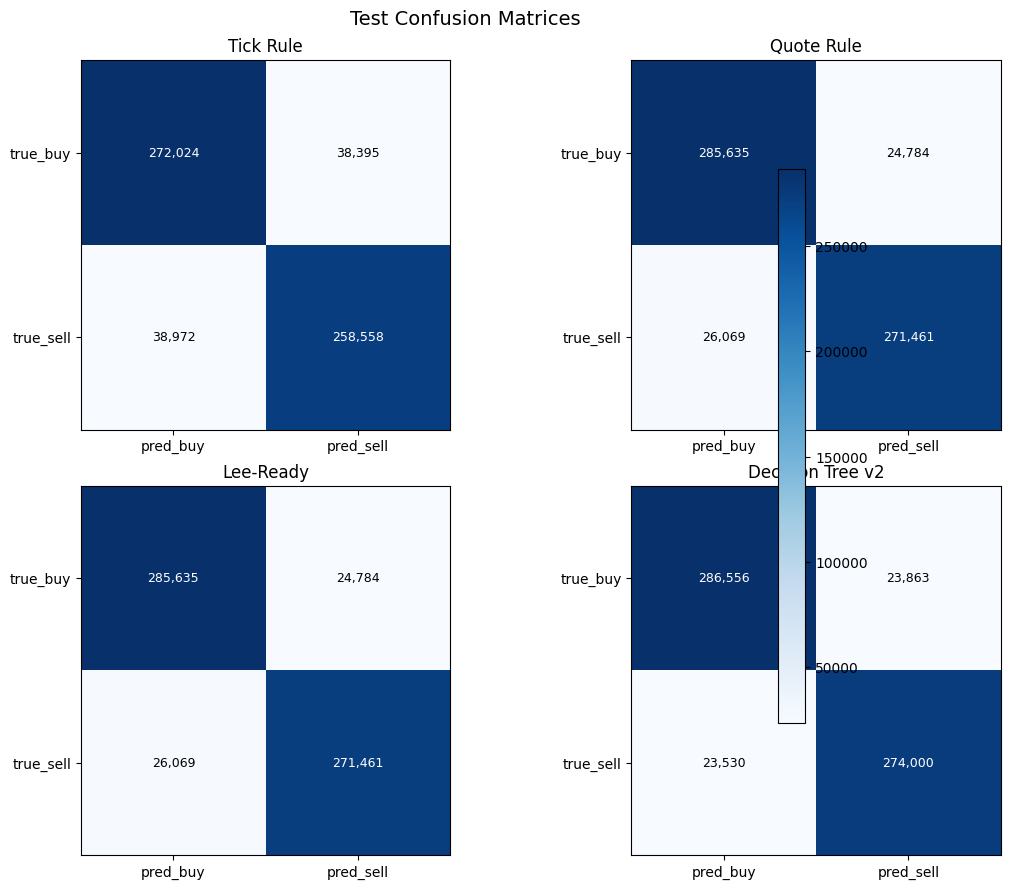

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.ravel()
order = ["Tick Rule", "Quote Rule", "Lee-Ready", "Decision Tree v2"]

for ax, name in zip(axes, order):
    cm = confusion_matrix(test_base["y_true"], preds_test[name], labels=[False, True])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xticks([0, 1], labels=["pred_buy", "pred_sell"])
    ax.set_yticks([0, 1], labels=["true_buy", "true_sell"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() * 0.5 else "black", fontsize=9)

fig.suptitle("Test Confusion Matrices", fontsize=14)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

## 5) Does Decision Tree v2 beat all 3 baselines?

We primarily check `errors = FP + FN` plus balanced-accuracy and macro-F1 differences.

In [13]:
dt_row = test_report.loc["Decision Tree v2"]
baseline_names = ["Tick Rule", "Quote Rule", "Lee-Ready"]

cmp_rows = []
for b in baseline_names:
    br = test_report.loc[b]
    cmp_rows.append({
        "baseline": b,
        "dt_errors": int(dt_row["errors"]),
        "baseline_errors": int(br["errors"]),
        "dt_better_on_errors": bool(dt_row["errors"] < br["errors"]),
        "dt_minus_baseline_bal_acc": float(dt_row["balanced_accuracy"] - br["balanced_accuracy"]),
        "dt_minus_baseline_macro_f1": float(dt_row["macro_f1"] - br["macro_f1"]),
    })

cmp_df = pd.DataFrame(cmp_rows).set_index("baseline")
cmp_df

,dt_errors,baseline_errors,dt_better_on_errors,dt_minus_baseline_bal_acc,dt_minus_baseline_macro_f1
baseline,,,,,
Tick Rule,47393,77367,True,0.049357,0.049333
Quote Rule,47393,50853,True,0.005750,0.005703
Lee-Ready,47393,50853,True,0.005750,0.005703


In [14]:
if cmp_df["dt_better_on_errors"].all():
    print("SUCCESS: Decision Tree v2 beats all 3 baselines by confusion-matrix error count.")
else:
    print("PARTIAL SUCCESS: not all baselines are beaten on errors.")
    print("In that case, run the extra-tuning section below.")

SUCCESS: Decision Tree v2 beats all 3 baselines by confusion-matrix error count.


### Executive summary

In [15]:
best_model = test_report.sort_values(["errors", "balanced_accuracy"], ascending=[True, False]).index[0]
dt_wins_all = bool(cmp_df["dt_better_on_errors"].all())

summary_lines = [
    f"Best model by error count on TEST: {best_model}.",
    f"Decision Tree v2 beats all 3 baselines on errors: {dt_wins_all}.",
    f"Decision Tree v2 errors: {int(dt_row['errors'])}.",
    f"Best baseline: {best_baseline_name} with {int(best_baseline['errors'])} errors.",
    f"Delta (DT - best baseline) errors: {int(dt_metrics['errors'] - best_baseline['errors'])}.",
    f"Decision Tree v2 balanced accuracy: {_fmt_pct(float(dt_row['balanced_accuracy']))}.",
    f"Decision Tree v2 macro F1: {_fmt_pct(float(dt_row['macro_f1']))}.",
]

for line in summary_lines:
    print("-", line)

- Best model by error count on TEST: Decision Tree v2.
- Decision Tree v2 beats all 3 baselines on errors: True.
- Decision Tree v2 errors: 47393.
- Best baseline: Quote Rule with 50853 errors.
- Delta (DT - best baseline) errors: -3460.
- Decision Tree v2 balanced accuracy: 92.20%.
- Decision Tree v2 macro F1: 92.20%.


## 6) Feature importance and interpretation

Top features to discuss 

,importance
mid_sign,0.952258
mid_abs_delta,0.014231
mid_delta,0.011234
ret_3,0.004949
log_amount,0.003196
tick_rule_side,0.002549
run_length,0.001616
ret_1,0.001615
tick_2,0.001592
log_dt_s,0.001272


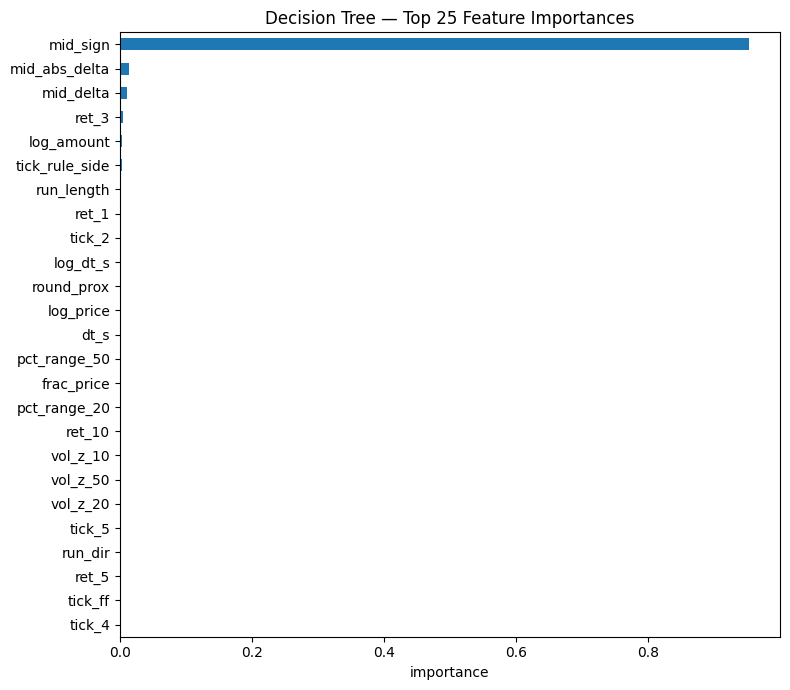

In [16]:
fi = pd.Series(
    dt_final.named_steps["clf"].feature_importances_,
    index=X_tv_clean.columns,
).sort_values(ascending=False)

display(fi.head(25).to_frame("importance"))

plt.figure(figsize=(8, 7))
fi.head(25).sort_values().plot(kind="barh")
plt.title("Decision Tree — Top 25 Feature Importances")
plt.xlabel("importance")
plt.tight_layout()
plt.show()